# Explosive Nucleosynthesis

Here we'll explore burning up to iron group.
To do this, we'll create a moderately-sized network that includes links from He up to iron-group.  And to make the integration easier, we'll do a few approximations along the way.

In [1]:
import pynucastro as pyna

## Assembling our library

We start with a list of nuclei, including all $\alpha$-nuclei up to ${}^{56}\mathrm{Ni}$.
We also add the intermediate nuclei that would participate in $(\alpha,p)(p,\gamma)$ reactions,
as well as a few more nuclei, including those identified by [Shen & Bildsten 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...699.1365S/abstract) for bypassing the ${}^{12}\mathrm{C}(\alpha,\gamma){}^{16}\mathrm{O}$ rate.

In [2]:
nuclei = ["p",
          "he4", "c12", "o16", "ne20", "mg24", "si28", "s32",
          "ar36", "ca40", "ti44", "cr48", "fe52", "ni56", "zn60",
          "al27", "p31", "cl35", "k39", "sc43", "v47",
          "mn51", "co55", "cu59",
          "n13", "n14", "f18", "ne21", "na22", "na23"]

For our initial library, we take all of the ReacLib rates that link these.

In [3]:
reaclib_lib = pyna.ReacLibLibrary()
core_lib = reaclib_lib.linking_nuclei(nuclei)

Now we'll add some more nuclei in the iron group.

In [4]:
iron_peak = ["n", "p", "he4",
             "mn51",
             "fe52", "fe53", "fe54", "fe55", "fe56",
             "co55", "co56", "co57",
             "ni56", "ni57", "ni58",
             "cu59", "zn60"]

We want the rates that connect these from ReacLib as well as tabulated weak rate compilations.

In [5]:
iron_reaclib = reaclib_lib.linking_nuclei(iron_peak)

weak_lib = pyna.TabularLibrary()
iron_weak_lib = weak_lib.linking_nuclei(iron_peak)

In [6]:
all_lib = core_lib + iron_reaclib + iron_weak_lib

### Detailed balance

Finally, we replace the reverse rates from ReacLib by rederiving them via detailed balance, and including the partition functions.

In [7]:
rates_to_derive = all_lib.backward().get_rates()

# now for each of those derived rates, look to see if the pair exists

for r in rates_to_derive:
    fr = all_lib.get_rate_by_nuclei(r.products, r.reactants)
    if fr:
        all_lib.remove_rate(r)
        d = pyna.DerivedRate(rate=fr, compute_Q=True, use_pf=True)
        all_lib.add_rate(d)

### Removing duplicates

There will be some duplicate rates now because we pulled rates both from ReacLib and from tabulated sources.  Here we keep the tabulated version of any duplicate rates.

In [8]:
all_lib.eliminate_duplicates()

## Creating the network and rate approximations

Now that we have our library, we can make a network.

In [9]:
net = pyna.PythonNetwork(libraries=[all_lib])

Next, we will do the $(\alpha,p)(p,\gamma)$ approximation and eliminate the intermediate nuclei

In [10]:
net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47"])
net.remove_nuclei(["cl35", "k39", "sc43", "v47"])

We will also approximate some of the neutron captures:

In [11]:
net.make_nn_g_approx(intermediate_nuclei=["fe53", "fe55", "ni57"])
net.remove_nuclei(["fe53", "fe55", "ni57"])

and finally, make some of the protons into NSE protons

In [12]:
# make all rates with A >= 48 use NSE protons
net.make_nse_protons(48)

### Visualizing the network

Let's visualize the network

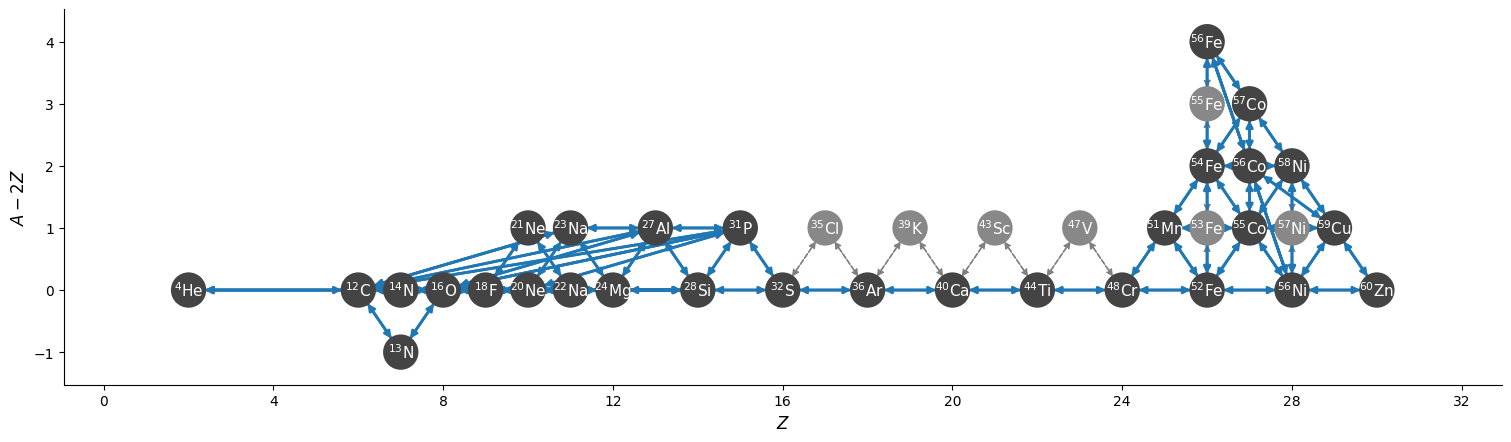

In [13]:
fig = net.plot(rotated=True, hide_xalpha=True,
               size=(1500, 450),
               node_size=550, node_font_size=11)

## Burning to iron-group

We'll write out the network to a python module and do a test integration with it.

In [14]:
net.write_network("he_burn.py")

/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:126: UserWarning: C12 partition function is not supported by tables: set pf = 1.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set pf = 1.0 by default'))
/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:126: UserWarning: N13 partition function is not supported by tables: set pf = 1.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set pf = 1.0 by default'))
/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:126: UserWarning: N14 partition function is not supported by tables: set pf = 1.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set pf = 1.0 by default'))
/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:126: UserWarning: p_nse partition function is not supported by tables: set pf = 1.0 by default
  warnings.warn(

In [15]:
import he_burn

In [16]:
from scipy.integrate import solve_ivp
import numpy as np

We'll pick thermodynamic conditions that are very dense and hot--we should enter NSE here.  And weak rates will also have a big effect, meaning that $Y_e$ should evolve.

Initially, we have $Y_e = 1/2$.

In [17]:
rho = 1.e9
T = 5.e9

X0 = np.zeros(he_burn.nnuc)
X0[he_burn.jhe4] = 0.98
X0[he_burn.jc12] = 0.02

Y0 = X0/he_burn.A

In [18]:
from pynucastro.screening import chugunov_2007

We'll specific the time-points where we want to store the solution.

In [19]:
tmax = 10.0
tmin = 1.e-11
factor = 6
n = factor * int(np.log10(tmax) - np.log10(tmin)) + 1
t_eval = np.logspace(np.log10(tmin), np.log10(tmax), n, endpoint=True)

In [20]:
sol = solve_ivp(he_burn.rhs, [0, tmax], Y0,
                method="BDF", jac=he_burn.jacobian,
                t_eval=t_eval, args=(rho, T, chugunov_2007),
                rtol=1.e-5, atol=1.e-8)

Was the integration successful?

In [21]:
sol.success

True

### Plotting the evolution

In [22]:
import matplotlib.pyplot as plt

Here we only plot the most abundant species

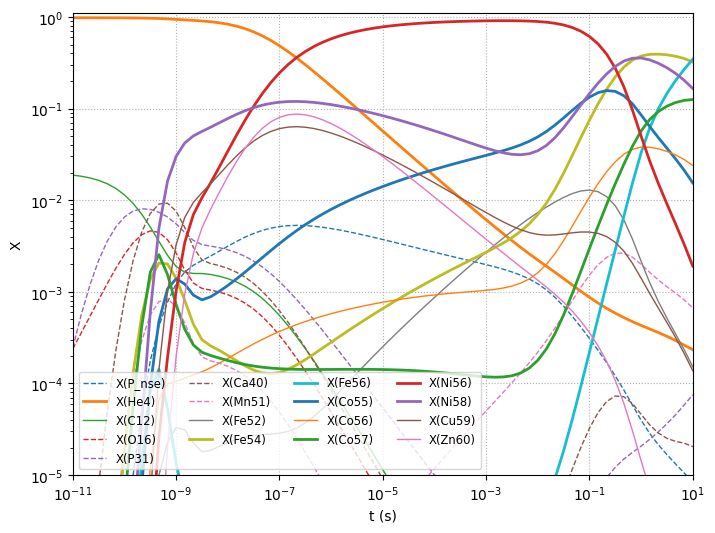

In [23]:
fig, ax = plt.subplots()

for i in range(he_burn.nnuc):
    Xmax = sol.y[i, :].max() * he_burn.A[i]
    if Xmax > 1.e-1:
        ax.loglog(sol.t, sol.y[i,:] * he_burn.A[i], linewidth=2,
                  label=f"X({he_burn.names[i].capitalize()})")
    elif Xmax > 1.e-2:
        ax.loglog(sol.t, sol.y[i,:] * he_burn.A[i], linewidth=1,
                  label=f"X({he_burn.names[i].capitalize()})")
    elif Xmax > 1.e-3:
        ax.loglog(sol.t, sol.y[i,:] * he_burn.A[i], linewidth=1, ls="--",
                  label=f"X({he_burn.names[i].capitalize()})")
        
ax.set_ylim(1.e-5, 1.1)
ax.legend(fontsize="small", ncol=4, loc=3)
ax.set_xlabel("t (s)")
ax.set_ylabel("X")
ax.margins(0)
ax.grid(ls=":")
fig.set_size_inches(8, 6)

### $Y_e$ evolution

In [24]:
X_final = sol.y[:, -1] * he_burn.A
comp = pyna.Composition(net.unique_nuclei)
comp.set_array(X_final)

Notice that $Y_e$ has changed a lot due to electron captures.

In [25]:
comp.ye

0.4750014049084172

### Visualizing network flow

Finally, we can visualize the evolution of the flow through the network.  We'll just work with a few of the times that were saved.  We'll also show the net rate between nuclei (forward - reverse rate) to make it clearer.

/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:126: UserWarning: C12 partition function is not supported by tables: set pf = 1.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set pf = 1.0 by default'))
/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:126: UserWarning: N13 partition function is not supported by tables: set pf = 1.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set pf = 1.0 by default'))
/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:126: UserWarning: N14 partition function is not supported by tables: set pf = 1.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set pf = 1.0 by default'))
/raid/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:126: UserWarning: p_nse partition function is not supported by tables: set pf = 1.0 by default
  warnings.warn(

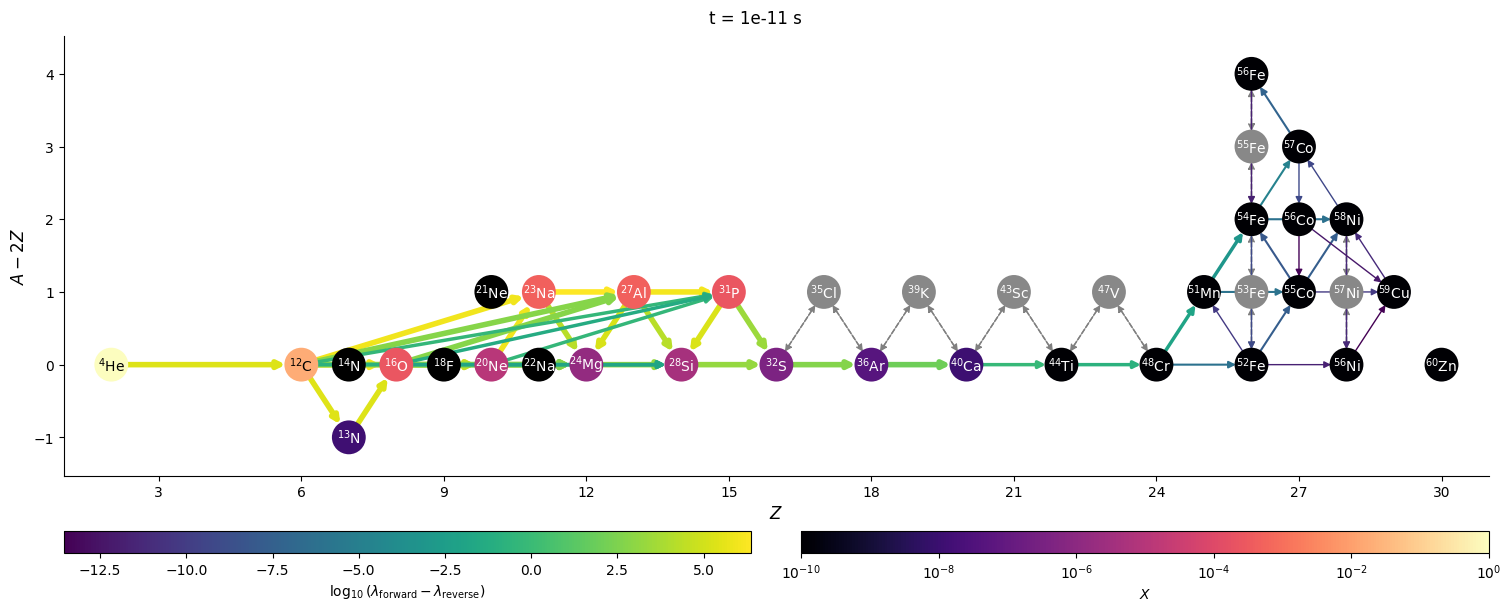

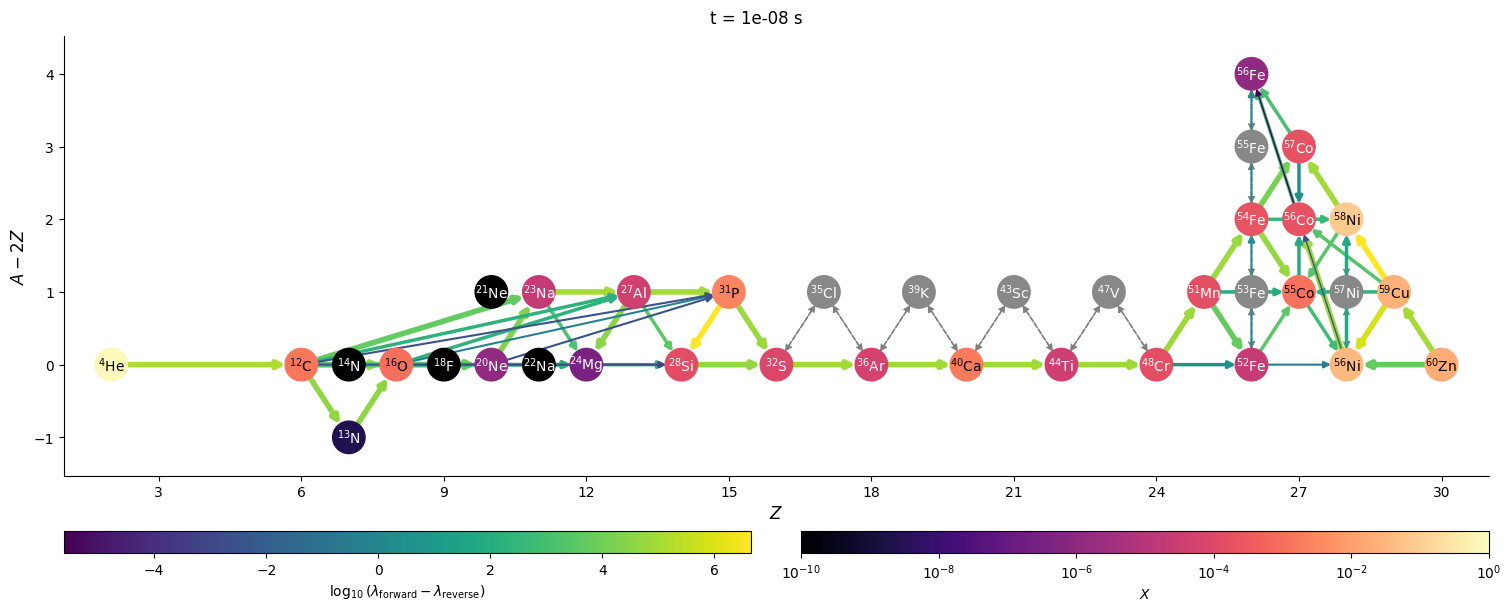

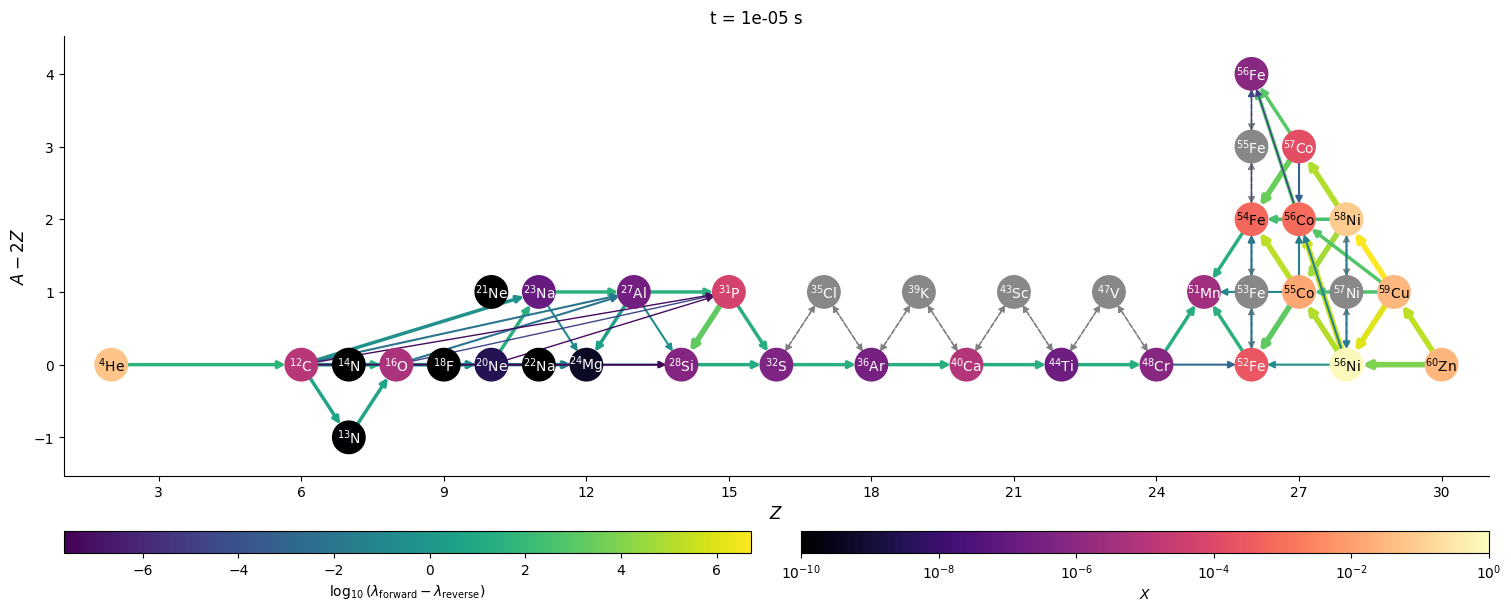

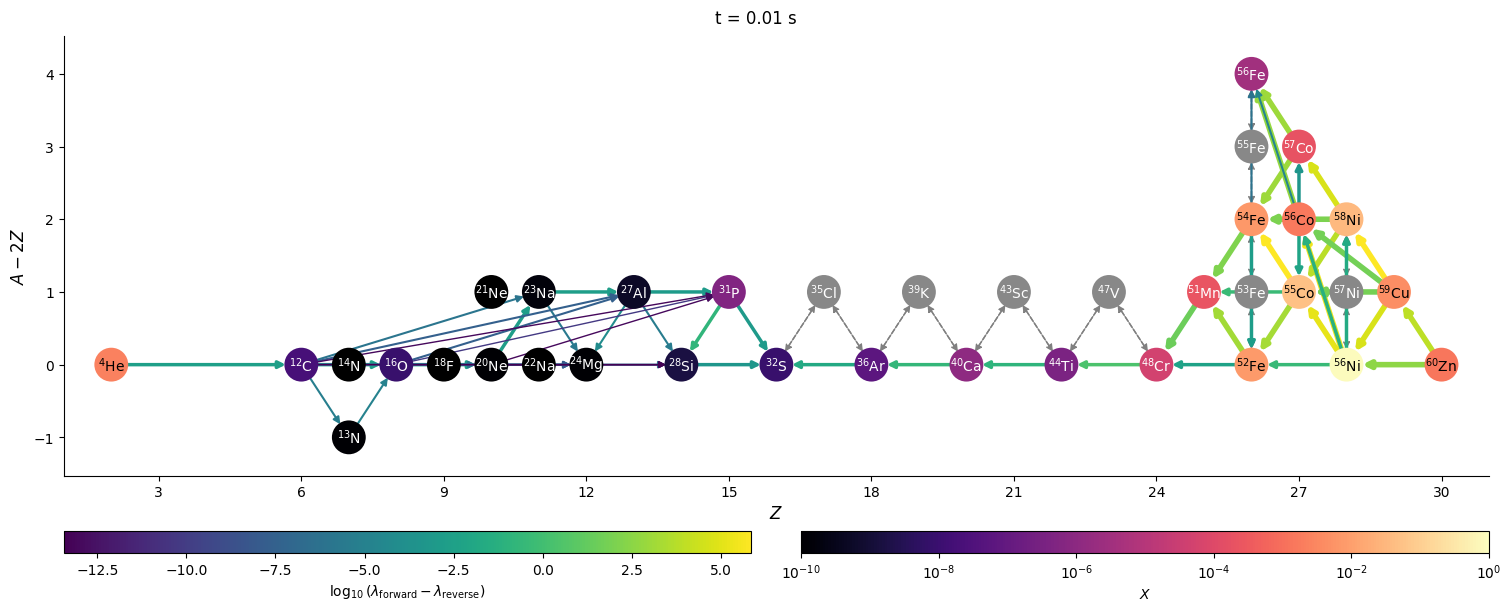

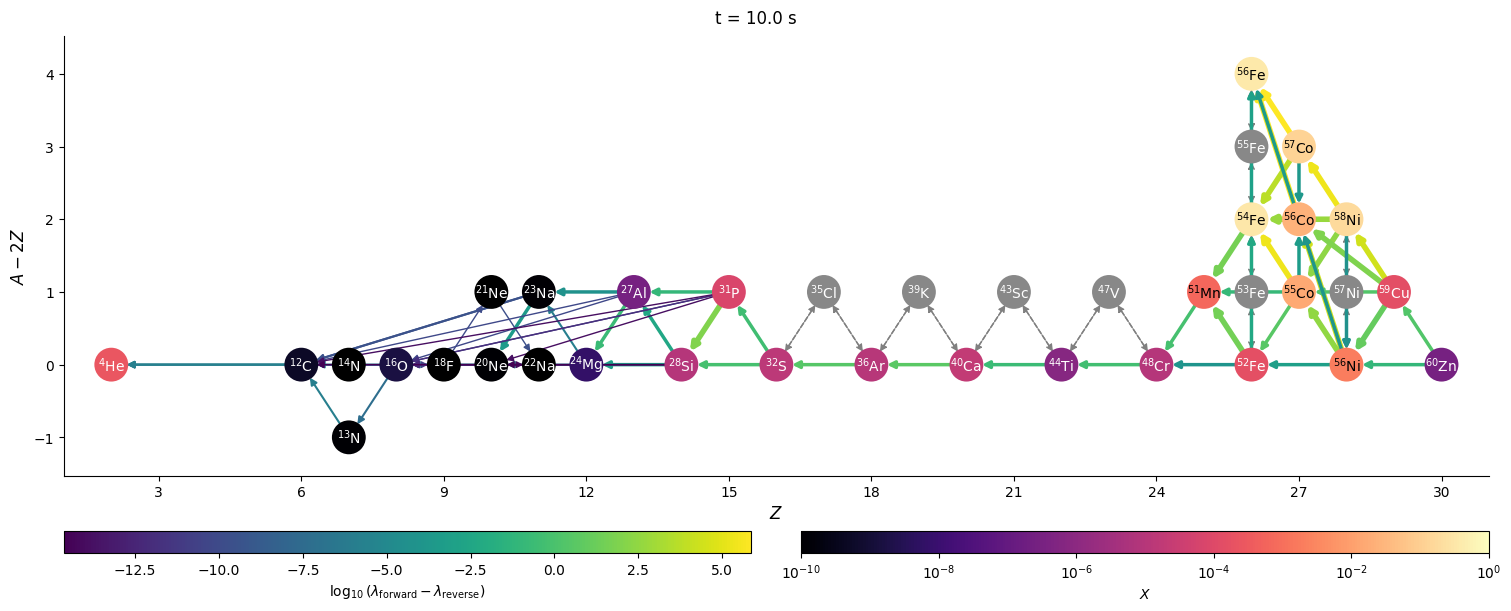

In [26]:
for idx in range(0, n, 3*factor):
    t = sol.t[idx]
    Y = sol.y[:, idx]
    comp.set_array(Y * he_burn.A)
    fig = net.plot(rho, T, comp,
                   rotated=True, hide_xalpha=True,
                   size=(1500, 600),                
                   ydot_cutoff_value=1.e-15,
                   use_net_rate=True,
                   color_nodes_by_abundance=True,
                   Z_range=(1, 31),
                   node_size=500, node_font_size=10)
    fig.suptitle(f"t = {t} s")